# ==============================================================================
# SCRIPT PYTHON - ENTRAÎNEMENT U-NET
# ==============================================================================
# But : Générer et entraîner le modèle de détection des terrasses. 
#       Charger les patchs, les diviser, procéder à l'augmentation de données, 
#       entraîner le modèle U-Net, puis l'évaluer (loss, accuracy, matrice).
# ==============================================================================


In [52]:
print('--- ÉTAPE 1 : Configuration de l\'environnement ---')

# Bibliothèques standard
import os
import json

# Bibliothèques de manipulation de données
import pandas as pd
import numpy as np
import random

# Bibliothèques de visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import ImageColor
from tensorflow.keras.models import load_model

# Bibliothèques de machine learning
import tensorflow as tf
from tensorflow.keras.regularizers import l1
import keras
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Dropout, concatenate, Input, BatchNormalization, Activation
from keras.models import Model
from keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras import backend as K
from skimage.transform import rotate

import gc

# Bibliothèques pour le traitement d'images et de données géospatiales
import rasterio as rio
from rasterio.enums import Resampling
import rasterio.warp as warp
from skimage.exposure import rescale_intensity
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from scipy.ndimage import rotate as ndi_rotate, zoom
from skimage.util import random_noise
from skimage.exposure import adjust_gamma
import cv2


# Paramètres pour la gestion du GPU
physical_devices = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)


K.clear_session()
gc.collect()

0

In [40]:
# Vérification de la configuration
print("Version de TensorFlow :", tf.__version__)
print("Version de CUDA :", tf.sysconfig.get_build_info()['cuda_version'])
print("Version de CuDNN :", tf.sysconfig.get_build_info()['cudnn_version'])
print("Nombre de GPUs disponible : ", len(tf.config.experimental.list_physical_devices('GPU')))

Version de TensorFlow : 2.17.0
Version de CUDA : 12.0
Version de CuDNN : 9
Nombre de GPUs disponible :  1


# ==============================================================================
# 2. CHARGEMENT ET PRÉPARATION DE LA LÉGENDE
# ==============================================================================


In [41]:
print('--- ÉTAPE 2 : Chargement des métadonnées (Légende) ---')

lc_dir = 'chemin/vers/votre/dossier/lc.json'             # Fichier json pour le style des rasters

#Load Land Cover Parameter
lc = json.load(open(lc_dir))
lc_df = pd.DataFrame(lc)
lc_df["values_normalize"] = lc_df.index + 1
lc_df["palette"] = "#" + lc_df["palette"]

# Mapping from old to new values
values = lc_df["values"].to_list()
values_norm = lc_df["values_normalize"].to_list()
palette = lc_df["palette"].to_list()
labels = lc_df["label"].to_list()
dict_values = {}
dict_label = {}
dict_palette = {}
dict_palette_hex = {}
for x in range(0, len(values)):
    dict_values[values[x]] = values_norm[x]
    dict_label[values_norm[x]] = labels[x]
    dict_palette[values_norm[x]] = ImageColor.getrgb(palette[x])
    dict_palette_hex[values_norm[x]] = palette[x]

# Create colormap from values and palette
cmap = ListedColormap(palette)

# Patches legend
patches = [
    mpatches.Patch(color=palette[i], label=labels[i]) for i in range(len(values))
]
legend = {
    "handles": patches,
    "bbox_to_anchor": (1.05, 1),
    "loc": 2,
    "borderaxespad": 0.0,
}

lc_df

,palette,values,label,values_normalize
0,#FFFFFF,0,Autre,1
1,#000000,1,Parcelle,2


# ==============================================================================
# 3. NETTOYAGE DES FICHIERS TEMP
# ==============================================================================


In [42]:
print('--- ÉTAPE 3 : Suppression des fichiers .aux.xml ---')

# Définir les chemins des dossiers
folders = [
    'chemin/vers/votre/dossier/data/images/',
    'chemin/vers/votre/dossier/data/lcs/'
]

# Fonction pour supprimer les fichiers .aux.xml
def delete_aux_files(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.aux.xml'):
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    print(f"Fichier supprimé : {file_path}")
                except Exception as e:
                    print(f"Erreur lors de la suppression de {file_path} : {e}")

# Parcourir les dossiers et supprimer les fichiers ciblés
for folder in folders:
    delete_aux_files(folder)

In [43]:
# load image sample
lc_values = os.listdir('chemin/vers/votre/dossier/data/images')
lc_values = list(map(lambda x: int(x.split('_')[0]), lc_values))
lc_values = np.unique(lc_values)
lc_values.sort()
lc_values

array([2])

# ==============================================================================
# 4. AUGMENTATION DES DONNÉES
# ==============================================================================
Les patchs chargés, soit l'image Landsat et l'étiquette de détection des terrasses, seront divisés en données de formation et de test en utilisant un ratio de 4:1. 

Après la division, toutes les données seront augmentées afin d'accroître la taille de l'échantillon et d'améliorer l'apprentissage du modèle.

## 4.1 Fonction d'augmentation des données

In [44]:
print('--- ÉTAPE 4 : Préparation de l\'augmentation des données ---')

# Paramètres
selected_bands = [0, 1, 2, 3, 4, 5, 6, 7]
image_per_lc = 604
index_train = int(9 / 10 * image_per_lc)

# Paramètres d'augmentation
APPLY_AUGMENTATION = True
FLIP_HORIZONTAL = True
FLIP_VERTICAL = True
ROTATIONS = [90, 180, 270]  # Rotations à appliquer (en degrés)
RESIZE_CROP_SCALE = 1.2  # Facteur de zoom pour resize+crop (ex: 1.2 = zoom de 20%)

def rotate_image(image, angle):
    """Rotation d'une image multi-canaux."""
    if image.ndim == 3:
        rotated = np.zeros_like(image)
        for i in range(image.shape[2]):
            rotated[:, :, i] = ndi_rotate(image[:, :, i], angle, reshape=False, order=1)
        return rotated
    else:  # Masque 2D — skimage.transform.rotate
        return rotate(image, angle, resize=False, order=0, preserve_range=True).astype(image.dtype)

def augment_image_mask(image, mask):
    """
    Applique l'augmentation de données sur une paire image/masque.
    Retourne une liste de tuples (image_augmentée, masque_augmenté).
    """
    augmented_pairs = [(image, mask)]  # Données originales
    
    # Flipping horizontal
    if FLIP_HORIZONTAL:
        augmented_pairs.append((np.fliplr(image), np.fliplr(mask)))
    
    # Flipping vertical
    if FLIP_VERTICAL:
        augmented_pairs.append((np.flipud(image), np.flipud(mask)))
    
    # Rotations
    for angle in ROTATIONS:
        img_rot = rotate_image(image, angle)
        mask_rot = rotate_image(mask, angle)
        augmented_pairs.append((img_rot, mask_rot))
    
    # Resize + Crop (zoom central)
    if RESIZE_CROP_SCALE > 1.0:
        h, w = image.shape[:2]
        
        # Zoom sur l'image
        zoom_factors = (RESIZE_CROP_SCALE, RESIZE_CROP_SCALE, 1)
        img_resized = zoom(image, zoom_factors, order=1)
        
        # Zoom sur le masque (ajuster selon si 2D ou 3D)
        if mask.ndim == 2:
            mask_zoom_factors = (RESIZE_CROP_SCALE, RESIZE_CROP_SCALE)
        else:
            mask_zoom_factors = (RESIZE_CROP_SCALE, RESIZE_CROP_SCALE, 1)
        mask_resized = zoom(mask, mask_zoom_factors, order=0)
        
        # Crop central pour retrouver la taille originale
        new_h, new_w = img_resized.shape[:2]
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        img_cropped = img_resized[start_h:start_h+h, start_w:start_w+w]
        mask_cropped = mask_resized[start_h:start_h+h, start_w:start_w+w]
        
        augmented_pairs.append((img_cropped, mask_cropped))
    
    return augmented_pairs  # ✅ CORRECTION ICI


# ==============================================================================
# 5. TRAITEMENT DES IMAGES ET DES MASQUES (SPLIT TRAIN/TEST)
# ==============================================================================


In [45]:
print('--- ÉTAPE 5 : Chargement des patchs et split train/test ---')

# ==============================
# CHARGEMENT IMAGES & MASQUES
# ==============================

images_train, images_test = [], []
lcs_train_raw, lcs_test_raw = [], []

images_dir = 'chemin/vers/votre/dossier/data/images'
masks_dir  = 'chemin/vers/votre/dossier/data/lcs'

for lc in lc_values:

    # --- Récupérer les IDs communs image / masque ---
    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.startswith(f"{lc}_") and f.endswith("_i.tif")
    ])

    mask_files = sorted([
        f for f in os.listdir(masks_dir)
        if f.startswith(f"{lc}_") and f.endswith("_m.tif")
    ])

    # Construire un mapping id → fichier
    image_dict = {
        int(f.split('_')[1]): f for f in image_files
    }
    mask_dict = {
        int(f.split('_')[1]): f for f in mask_files
    }

    # Garder uniquement les IDs communs
    common_ids = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    for y, idx in enumerate(common_ids):

        if idx >= image_per_lc:
            continue

        # --- IMAGE ---
        img_path = os.path.join(images_dir, image_dict[idx])
        with rio.open(img_path) as src:
            img = np.transpose(src.read(), (1, 2, 0))[:, :, selected_bands]

        # --- MASQUE ---
        mask_path = os.path.join(masks_dir, mask_dict[idx])
        with rio.open(mask_path) as src:
            mask = np.transpose(src.read(), (1, 2, 0))

        # --- SPLIT TRAIN / TEST ---
        if y < index_train:
            if APPLY_AUGMENTATION:
                pairs = augment_image_mask(img, mask.squeeze(-1))
                for img_aug, mask_aug in pairs:
                    images_train.append(img_aug)
                    lcs_train_raw.append(mask_aug[..., np.newaxis])
            else:
                images_train.append(img)
                lcs_train_raw.append(mask)
        else:
            images_test.append(img)
            lcs_test_raw.append(mask)

        # Conversion en numpy
images_train = np.stack(images_train)
images_test  = np.stack(images_test)
lcs_train    = np.stack(lcs_train_raw)
lcs_test     = np.stack(lcs_test_raw)

print("\n=== CALCUL MIN/MAX SUR DONNÉES BRUTES ===")
train_min_raw = images_train.min(axis=(0,1,2))
train_max_raw = images_train.max(axis=(0,1,2))

print(f"train_min BRUT: {train_min_raw}")
print(f"train_max BRUT: {train_max_raw}")


print('\n--- ÉTAPE 6 : Normalisation et validation de la correspondance ---')
# ==============================
# NORMALISATION DES IMAGES (par bande)
# ==============================

images_train = images_train.astype(np.float32)
images_test  = images_test.astype(np.float32)

# images_train shape : (N, H, W, 8)
train_min = images_train.min(axis=(0,1,2))  # shape: (8,)
train_max = images_train.max(axis=(0,1,2))  # shape: (8,)

# Split manuel AVANT normalisation
split_idx = int(len(images_train) * 0.9)
X_train, X_val = images_train[:split_idx], images_train[split_idx:]


# Normaliser uniquement sur X_train
train_min = X_train.min(axis=(0,1,2))
train_max = X_train.max(axis=(0,1,2))

np.save("chemin/vers/votre/dossier/data/train_min.npy", train_min)
np.save("chemin/vers/votre/dossier/data/train_max.npy", train_max)

X_train     = (X_train     - train_min) / (train_max - train_min + 1e-8)
X_val       = (X_val       - train_min) / (train_max - train_min + 1e-8)
images_test = (images_test - train_min) / (train_max - train_min + 1e-8)


# ==============================
# DIAGNOSTICS OBLIGATOIRES
# ==============================

print("=== DATA CHECK ===")
print(f"Images train brut : {images_train.shape}")
print(f"Masks train brut  : {lcs_train.shape}")
print(f"Images test       : {images_test.shape}")
print(f"Masks test        : {lcs_test.shape}")
assert images_train.shape[0] == lcs_train.shape[0], "❌ Désalignement TRAIN"
assert images_test.shape[0]  == lcs_test.shape[0],  "❌ Désalignement TEST"
print(f"✅ Alignement OK — {images_train.shape[0]} images train, {images_test.shape[0]} images test")
print(f"   → Augmentation ×6 : {images_train.shape[0]} = {images_train.shape[0]//6} originales × 6")



=== CALCUL MIN/MAX SUR DONNÉES BRUTES ===
train_min BRUT: [0.03137255 0.01612903 0.0244898  0.         0.         0.
 0.         0.1352265 ]
train_max BRUT: [0.98039216 1.         1.         0.69284886 0.97195756 0.8210491
 1.         0.98875296]
=== DATA CHECK ===
Images train brut : (3801, 128, 128, 8)
Masks train brut  : (3801, 128, 128, 1)
Images test       : (60, 128, 128, 8)
Masks test        : (60, 128, 128, 1)
✅ Alignement OK — 3801 images train, 60 images test
   → Augmentation ×6 : 3801 = 633 originales × 6


# ==============================================================================
# 6. TRAITEMENTS DES LABELS (MASQUES EN CATÉGORIES)
# ==============================================================================


In [46]:
#images_train = images_train.astype(np.float32)
#images_test  = images_test.astype(np.float32)
#
## Split AVANT normalisation (mais après cast float32)
#split_idx = int(len(images_train) * 0.9)
#X_train, X_val = images_train[:split_idx], images_train[split_idx:]

In [47]:
print('--- ÉTAPE 7 : Traitement des masques et One-Hot Encoding ---')

# ==============================
# LABELS : normalisation + split + one-hot
# ==============================
lcs_train_normalized = lcs_train.squeeze(-1) - 1
lcs_test_normalized  = lcs_test.squeeze(-1)  - 1

lcs_train_category = to_categorical(lcs_train_normalized, num_classes=2)
lcs_test_category  = to_categorical(lcs_test_normalized,  num_classes=2)

y_train = lcs_train_category[:split_idx]
y_val   = lcs_train_category[split_idx:]

# Diagnostic
print("=== DIAGNOSTIC ===")
print(f"X_train shape:     {X_train.shape}")
print(f"X_train min/max:   {X_train.min():.4f} / {X_train.max():.4f}")
print(f"X_val shape:       {X_val.shape}")
print(f"y_train shape:     {y_train.shape}")
print(f"y_val shape:       {y_val.shape}")
print(f"Valeurs uniques masques train: {np.unique(lcs_train_normalized)}")

class_0 = np.sum(lcs_train_normalized == 0)
class_1 = np.sum(lcs_train_normalized == 1)
total   = lcs_train_normalized.size
print(f"Classe 0: {class_0} pixels ({class_0/total*100:.2f}%)")
print(f"Classe 1: {class_1} pixels ({class_1/total*100:.2f}%)")

# input_shape basé sur X_train (pas images_train)
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])

=== DIAGNOSTIC ===
X_train shape:     (3420, 128, 128, 8)
X_train min/max:   0.0000 / 1.0000
X_val shape:       (381, 128, 128, 8)
y_train shape:     (3420, 128, 128, 2)
y_val shape:       (381, 128, 128, 2)
Valeurs uniques masques train: [0 1]
Classe 0: 55101317 pixels (88.48%)
Classe 1: 7174267 pixels (11.52%)


# ==============================================================================
# 7. CRÉATION DE L'ARCHITECTURE U-NET
# ==============================================================================
Ce script contient la fonction, les paramètres et la structure du modèle U-Net pour classer la détection des terrasses à partir d'une image (BD Ortho).

Il est possible de modifier le nombre de neurones et le kernel si vous souhaitez ajuster le nombre de couches ou la fenêtre dans laquelle le modèle apprend.

Plus il y a de couches, plus le modèle est grand et plus le kernel est grand, plus le modèle est généralisé.

In [50]:
print('--- ÉTAPE 8 : Création et architecture du modèle U-Net ---')

# Faire en sorte que les images soient de forme (hauteur, largeur, canaux)
input_shape = images_train.shape
input_shape = (input_shape[1], input_shape[2], input_shape[3])

# Hyperparametres
epochs = 30
learning_rate = 0.0005
neuron = 32
batch_size=32
kernel = 3
kernel_t = 2
dropout = 0.2
strides = 2
pool = 2
padding = 'same'
input_layer = Input(input_shape)

def conv2_block(input, neuron):
    x = Conv2D(neuron, kernel, padding=padding)(input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(neuron, kernel, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def encode(input, neuron):
    conv = conv2_block(input, neuron)
    mp = MaxPooling2D(2)(conv)
    return conv, mp  # plus de Dropout ici

def decode(input, conv, neuron):
    conv_t = Conv2DTranspose(neuron, kernel_t, strides, padding=padding)(input)
    concat = concatenate([conv_t, conv])
    x = conv2_block(concat, neuron)
    return x  # plus de Dropout ici

conv1, mp1 = encode(input_layer, neuron * 1)
conv2, mp2 = encode(mp1, neuron * 2)
conv3, mp3 = encode(mp2, neuron * 4)
conv4, mp4 = encode(mp3, neuron * 8)
transition = conv2_block(mp4, neuron * 16)
transition = Dropout(0.3)(transition)  # Dropout uniquement ici
uncov1 = decode(transition, conv4, neuron * 8)
uncov2 = decode(uncov1, conv3, neuron * 4)
uncov3 = decode(uncov2, conv2, neuron * 2)
uncov4 = decode(uncov3, conv1, neuron * 1)
output = Conv2D(2, 1, padding=padding, activation='softmax')(uncov4)  # 2 classes au lieu de 3
model = Model(input_layer, output)
#model.summary()

In [ ]:
print('--- ÉTAPE 9 : Compilation et Entraînement ---')

# Calculer les poids de classe
from sklearn.utils.class_weight import compute_class_weight

y_flat = lcs_train_normalized[:split_idx].flatten()  # uniquement le train
class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_flat),
    y=y_flat
)

print(f"\n=== POIDS DE CLASSE ===")
for i, weight in enumerate(class_weight_array):
    print(f"Classe {i}: poids = {weight:.4f}")


# Compiler avec la loss pondérée
def focal_dice_loss(y_true, y_pred, gamma=2.0, alpha=0.85):
    smooth = 1e-6

    # --- Focal Loss ---
    y_pred_clipped = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    # Alpha inversé : pénalise plus la classe minoritaire (classe 1)
    alpha_t = y_true[..., 0] * (1 - alpha) + y_true[..., 1] * alpha
    p_t     = tf.reduce_sum(y_true * y_pred_clipped, axis=-1)
    focal   = -alpha_t * tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t)
    focal_loss = tf.reduce_mean(focal)

    # --- Dice Loss sur classe minoritaire (index 1) ---
    y_true_f = tf.reshape(y_true[..., 1], [-1])
    y_pred_f = tf.reshape(y_pred_clipped[..., 1], [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice_loss = 1 - (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

    return focal_loss + dice_loss

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss=bce_dice_loss,
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.MeanIoU(num_classes=2)
    ]
)


callbacks = [
    EarlyStopping(
        patience=7,
        monitor='val_loss',
        mode='min',
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]


# Entraîner SANS class_weight
result = model.fit(
    x=X_train,
    y=y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)


=== POIDS DE CLASSE ===
Classe 0: poids = 0.5638
Classe 1: poids = 4.4160
Epoch 1/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - categorical_accuracy: 0.8168 - loss: 1.2126 - mean_io_u: 0.2500

2026-02-17 10:41:48.712463: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng27{k2=1,k5=3,k14=2} for conv (f32[28,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,32,128,128]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-02-17 10:41:48.719566: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.357631982s
Trying algorithm eng27{k2=1,k5=3,k14=2} for conv (f32[28,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,32,128,128]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"op

107/107 ━━━━━━━━━━━━━━━━━━━━ 56s 311ms/step - categorical_accuracy: 0.8173 - loss: 1.2111 - mean_io_u: 0.2500 - val_categorical_accuracy: 0.8534 - val_loss: 1.2675 - val_mean_io_u: 0.2500
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - categorical_accuracy: 0.8576 - loss: 1.0429 - mean_io_u: 0.2500 - val_categorical_accuracy: 0.4058 - val_loss: 1.5611 - val_mean_io_u: 0.2500
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - categorical_accuracy: 0.8593 - loss: 1.0121 - mean_io_u: 0.2500 - val_categorical_accuracy: 0.6909 - val_loss: 1.2693 - val_mean_io_u: 0.2504
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - categorical_accuracy: 0.8635 - loss: 0.9859 - mean_io_u: 0.2500 - val_categorical_accuracy: 0.7367 - val_loss: 1.2081 - val_mean_io_u: 0.2555
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - categorical_accuracy: 0.8617 - loss: 0.9630 - mean_io_u: 0.2500 - val_categorical_accuracy: 0.8365 - val_loss: 1.0057 - val_mean_io_u: 0.2500
Epoch 6/30
107/1

# ==============================================================================
# 8. EVALUATION ET GRAPHIQUES
# ==============================================================================


    categorical_accuracy      loss  mean_io_u  val_categorical_accuracy  \
0               0.839332  1.129594   0.250000                  0.853444   
1               0.855292  1.034012   0.250000                  0.405833   
2               0.858994  1.006375   0.250073                  0.690919   
3               0.862549  0.981069   0.250000                  0.736719   
4               0.864694  0.964114   0.250000                  0.836524   
5               0.866137  0.952993   0.250001                  0.824693   
6               0.868613  0.935393   0.250000                  0.838704   
7               0.870099  0.932898   0.250093                  0.868464   
8               0.870848  0.920884   0.250032                  0.834900   
9               0.875928  0.890014   0.250006                  0.728393   
10              0.879687  0.877669   0.250045                  0.832250   
11              0.882160  0.857349   0.250001                  0.798215   

    val_loss  val_mean_i

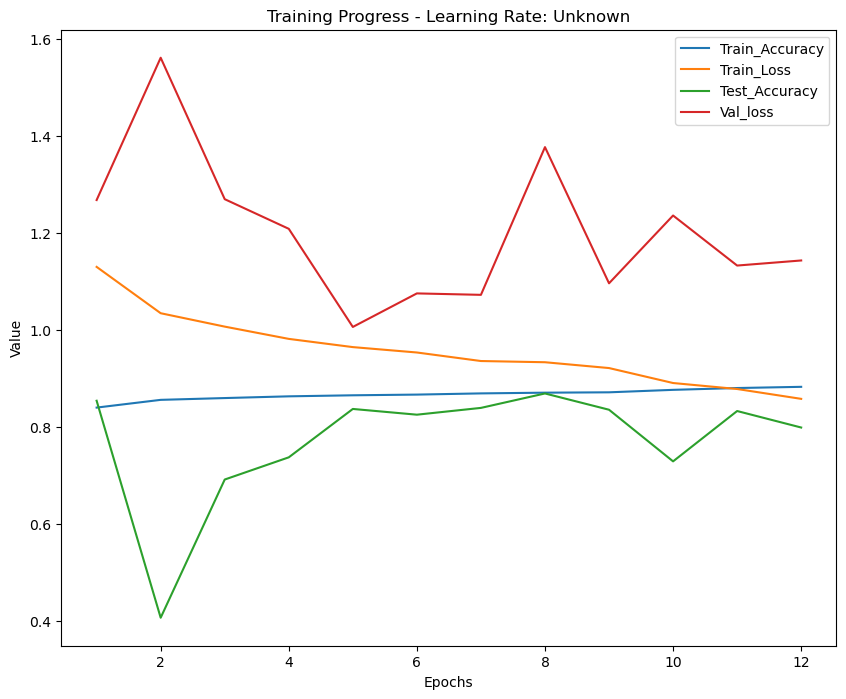

In [54]:
print('--- ÉTAPE 10 : Évaluation des performances du modèle ---')

# Imprimer le résumé statistique 
history = pd.DataFrame(result.history)
print(history)

# Récupérer les valeurs des epochs et du learning rate
epochs = range(1, len(history) + 1)
learning_rate = history['lr'].values if 'lr' in history.columns else None

plt.figure(figsize=(10, 8))
plt.plot(epochs, history['categorical_accuracy'], label='Train_Accuracy')
plt.plot(epochs, history['loss'], label='Train_Loss')
plt.plot(epochs, history['val_categorical_accuracy'], label='Test_Accuracy')
plt.plot(epochs, history['val_loss'], label='Val_loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.title(f'Training Progress - Learning Rate: {learning_rate[-1] if learning_rate is not None else "Unknown"}')
plt.show()

# Affichage du learning rate séparément si disponible
if learning_rate is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, learning_rate, label='Learning Rate', color='purple')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.legend()
    plt.show()

In [55]:
print(f"Classe 0: {np.sum(lcs_train_normalized == 0) / lcs_train_normalized.size * 100:.1f}%")
print(f"Classe 1: {np.sum(lcs_train_normalized == 1) / lcs_train_normalized.size * 100:.1f}%")

Classe 0: 88.5%
Classe 1: 11.5%


# ==============================================================================
# 9. PRÉDICTIONS ET MATRICE DE CONFUSION
# ==============================================================================
Une fois le modèle entraîné, il est appliqué aux données de test.

Les données de test appliquées sont ensuite comparées aux véritables parcelles d'étiquettes de détection des terrasses des données de test.

L'évaluation est effectuée à l'aide du rapport de classification et de la matrice de confusion.

In [ ]:
print('--- ÉTAPE 11 : Génération des prédictions ---')

# Appliquer un threshold sur les probabilités pour obtenir la classe prédite
threshold = 0.5  # à ajuster
proba_pred = model.predict(images_test, batch_size=8)
prediction = (proba_pred[..., 1] > threshold).astype(int).flatten()
label = lcs_test_normalized.flatten()  # Utiliser les labels normalisés (0 et 1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 531ms/step


Utilisation de 60 échantillons
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Unique label: [0 1]
Unique prediction: [0 1]
              precision    recall  f1-score   support

           0       0.84      0.79      0.81    796428
           1       0.29      0.38      0.33    186612

    accuracy                           0.71    983040
   macro avg       0.57      0.58      0.57    983040
weighted avg       0.74      0.71      0.72    983040



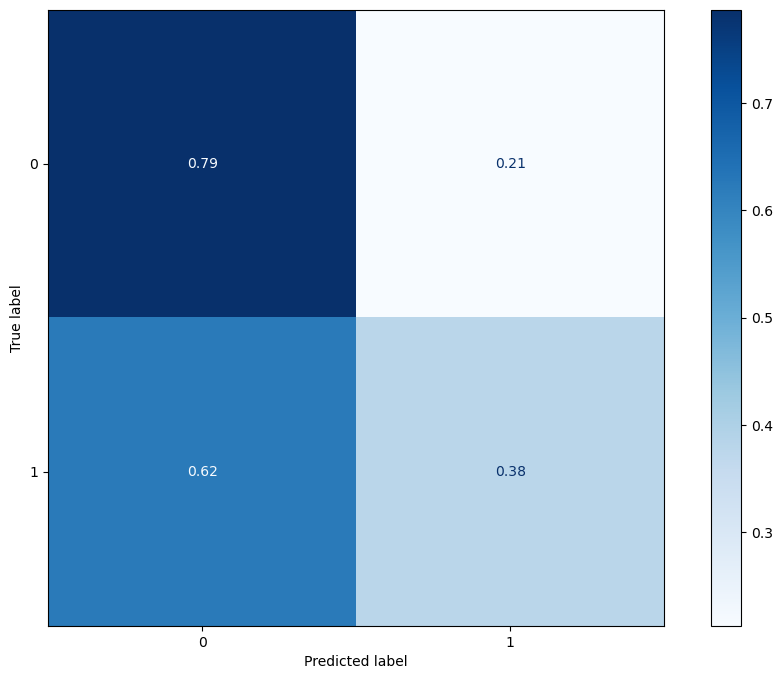

In [ ]:
print('--- ÉTAPE 12 : Matrice de confusion et Classification Report ---')

# Aligner les données sur le minimum
n_samples = min(len(images_test), len(lcs_test))
print(f"Utilisation de {n_samples} échantillons")

images_test_aligned = images_test[:n_samples]

# UTILISER LES MASQUES NORMALISÉS (0 / 1)
labels_test_aligned = lcs_test_normalized[:n_samples]

# Prédictions
prediction = np.argmax(
    model.predict(images_test_aligned, batch_size=8),
    axis=3
).flatten()

label = labels_test_aligned.flatten()

# Sécurité
print("Unique label:", np.unique(label))
print("Unique prediction:", np.unique(prediction))


cm = confusion_matrix(
    label,
    prediction,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=ax, cmap='Blues', values_format='.2f')

print(classification_report(label, prediction, labels=[0, 1]))

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

=== STATISTIQUES DES PRÉDICTIONS ===
Classe 0 prédite: 742,826 pixels (75.56%)
Classe 1 prédite: 240,214 pixels (24.44%)

=== SAUVEGARDE DE 20 IMAGES ===
✓ Image 1/20 sauvegardée
✓ Image 2/20 sauvegardée
✓ Image 3/20 sauvegardée


/home/vertex_wsl/miniconda3/envs/myenv_conda2/lib/python3.10/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


✓ Image 4/20 sauvegardée
✓ Image 5/20 sauvegardée
✓ Image 6/20 sauvegardée
✓ Image 7/20 sauvegardée
✓ Image 8/20 sauvegardée
✓ Image 9/20 sauvegardée
✓ Image 10/20 sauvegardée
✓ Image 11/20 sauvegardée
✓ Image 12/20 sauvegardée
✓ Image 13/20 sauvegardée
✓ Image 14/20 sauvegardée
✓ Image 15/20 sauvegardée
✓ Image 16/20 sauvegardée
✓ Image 17/20 sauvegardée
✓ Image 18/20 sauvegardée
✓ Image 19/20 sauvegardée
✓ Image 20/20 sauvegardée


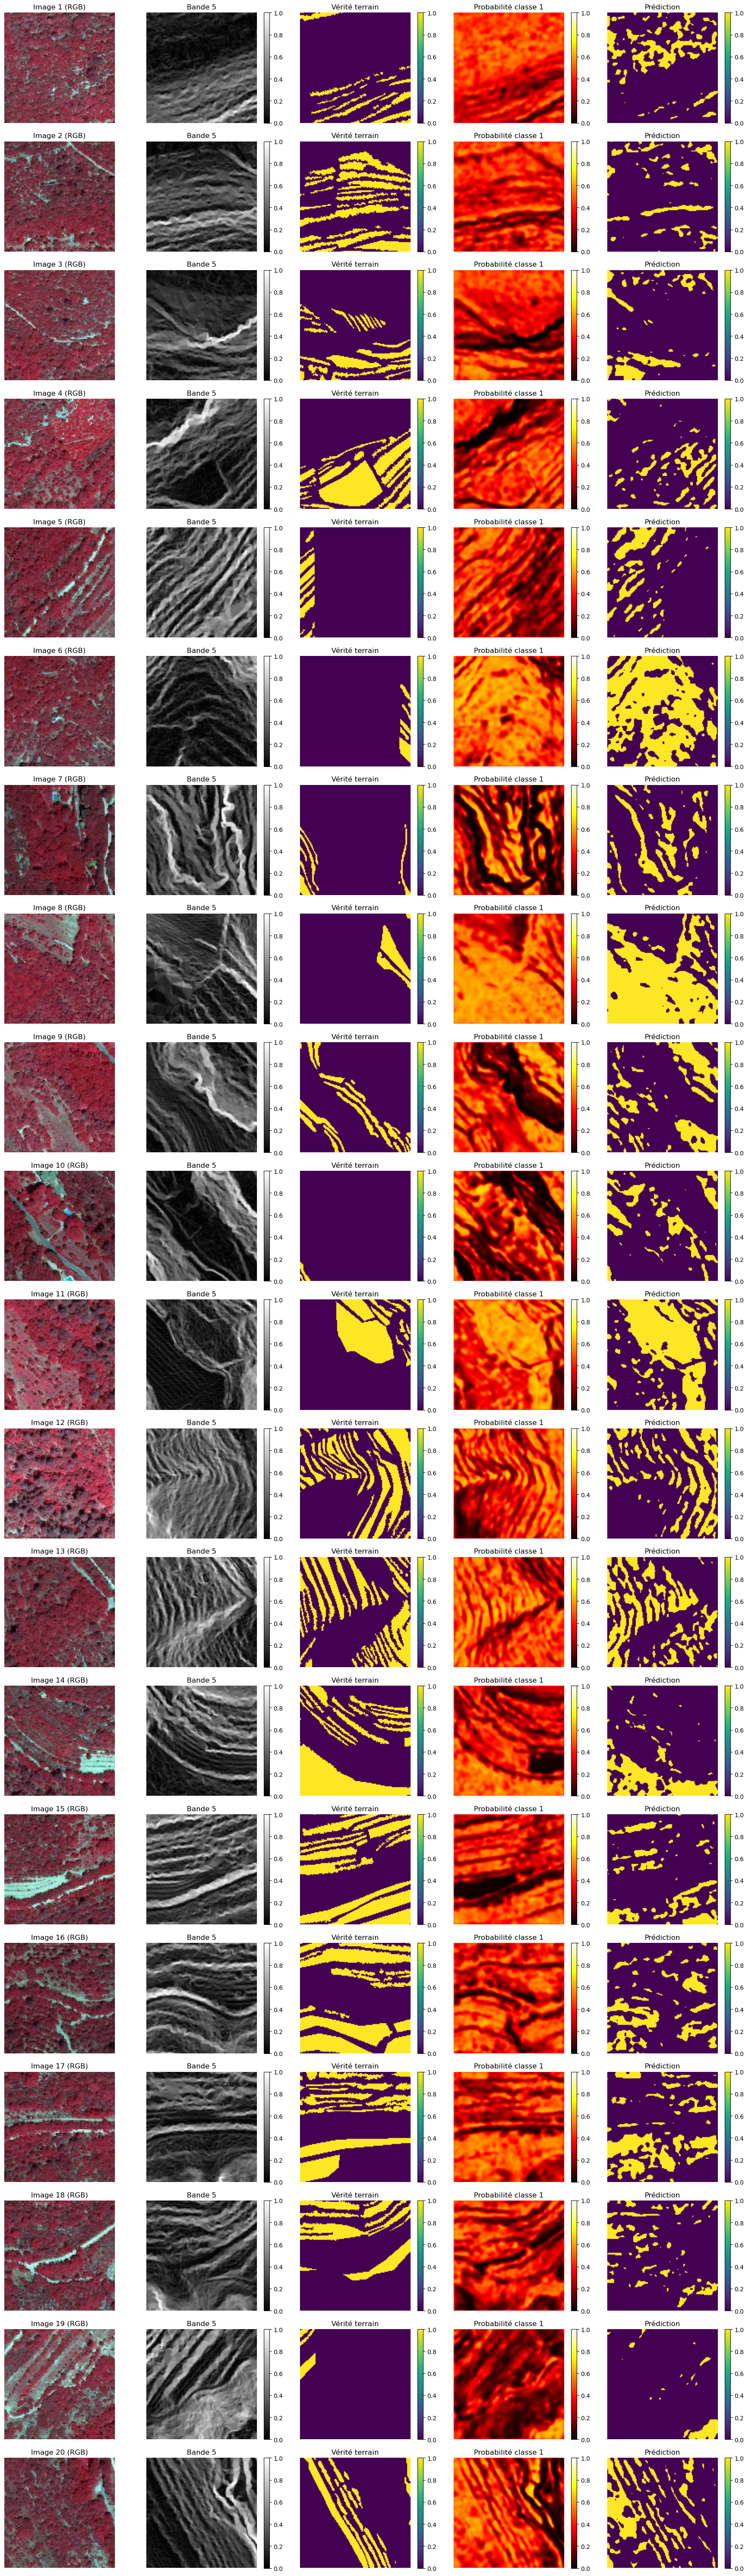


✅ 20 images sauvegardées dans: chemin/vers/votre/dossier/predictions
   - 20 probabilités classe 1
   - 20 prédictions finales
   - 20 bandes 5
   - Total: 60 fichiers .tif


In [ ]:
# Créer le dossier de sortie
output_dir = 'chemin/vers/votre/dossier/predictions'
os.makedirs(output_dir, exist_ok=True)

# Prédictions complètes (avec probabilités)
predictions_proba = model.predict(images_test, batch_size=8)  # (n, h, w, 2)
predictions_class = np.argmax(predictions_proba, axis=3)      # (n, h, w)

print(f"\n=== STATISTIQUES DES PRÉDICTIONS ===")
for i in range(2):
    count = np.sum(predictions_class == i)
    percentage = (count / predictions_class.size) * 100
    print(f"Classe {i} prédite: {count:,} pixels ({percentage:.2f}%)")

# Limiter à 20 images maximum
num_images_to_save = min(20, len(images_test))
print(f"\n=== SAUVEGARDE DE {num_images_to_save} IMAGES ===")

# 5 colonnes maintenant
plt.figure(figsize=(18, num_images_to_save * 3))

for x in range(num_images_to_save):

    # === 1. IMAGE RGB ===
    plt.subplot(num_images_to_save, 5, x * 5 + 1)
    rgb_image = images_test[x, :, :, :3]
    rgb_display = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min() + 1e-8)
    plt.imshow(rgb_display)
    plt.title(f'Image {x+1} (RGB)')
    plt.axis('off')

    # === 2. BANDE 5 ===
    plt.subplot(num_images_to_save, 5, x * 5 + 2)
    band5 = images_test[x, :, :, 4]
    band5_display = (band5 - band5.min()) / (band5.max() - band5.min() + 1e-8)
    plt.imshow(band5_display, cmap='gray')
    plt.title('Bande 5')
    plt.colorbar()
    plt.axis('off')

    # === 3. MASQUE RÉEL ===
    plt.subplot(num_images_to_save, 5, x * 5 + 3)
    plt.imshow(lcs_test_normalized[x], cmap='viridis', vmin=0, vmax=1)
    plt.title('Vérité terrain')
    plt.colorbar()
    plt.axis('off')

    # === 4. PROBABILITÉ CLASSE 1 ===
    plt.subplot(num_images_to_save, 5, x * 5 + 4)
    proba_class1 = predictions_proba[x, :, :, 1]
    plt.imshow(proba_class1, cmap='hot', vmin=0, vmax=1)
    plt.title('Probabilité classe 1')
    plt.colorbar()
    plt.axis('off')

    # === 5. PRÉDICTION FINALE ===
    plt.subplot(num_images_to_save, 5, x * 5 + 5)
    plt.imshow(predictions_class[x], cmap='viridis', vmin=0, vmax=1)
    plt.title('Prédiction')
    plt.colorbar()
    plt.axis('off')

    # ======================
    # SAUVEGARDE EN .TIF
    # ======================

    # Probabilité classe 1
    with rio.open(
        f'{output_dir}/proba_class1_image_{x+1}.tif',
        'w',
        driver='GTiff',
        height=proba_class1.shape[0],
        width=proba_class1.shape[1],
        count=1,
        dtype='float32',
        compress='lzw'
    ) as dst:
        dst.write(proba_class1.astype(np.float32), 1)

    # Prédiction finale
    with rio.open(
        f'{output_dir}/prediction_image_{x+1}.tif',
        'w',
        driver='GTiff',
        height=predictions_class[x].shape[0],
        width=predictions_class[x].shape[1],
        count=1,
        dtype='uint8',
        compress='lzw'
    ) as dst:
        dst.write(predictions_class[x].astype(np.uint8), 1)

    # Bande 5
    with rio.open(
        f'{output_dir}/band5_image_{x+1}.tif',
        'w',
        driver='GTiff',
        height=band5.shape[0],
        width=band5.shape[1],
        count=1,
        dtype='float32',
        compress='lzw'
    ) as dst:
        dst.write(band5.astype(np.float32), 1)

    print(f"✓ Image {x+1}/{num_images_to_save} sauvegardée")

plt.tight_layout()
plt.savefig(f'{output_dir}/all_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ {num_images_to_save} images sauvegardées dans: {output_dir}")
print(f"   - {num_images_to_save} probabilités classe 1")
print(f"   - {num_images_to_save} prédictions finales")
print(f"   - {num_images_to_save} bandes 5")
print(f"   - Total: {num_images_to_save * 3} fichiers .tif")


In [ ]:
# Calculer les stats sur les données brutes (avant division par 255 ou autre)
train_min = float(images_train.min())
train_max = float(images_train.max())

# Sauvegarder dans un fichier JSON pour l'inférence
import json
stats = {"min": train_min, "max": train_max}
with open('norm_stats.json', 'w') as f:
    json.dump(stats, f)

print(f"Stats sauvegardées : Min={train_min}, Max={train_max}")

Stats sauvegardées : Min=0.0, Max=1.0
